# T59 — Deep-time porphyry-Cu deposit trajectories: transient fertility windows in the North American Cordillera

**Cluster L: Mineral exploration.**

*Based on:* Norbisrath, J.H., Singh, S.P., Singh, U., Müller, R.D. (submitted, *Geology*) — *Plate reorganisation and carbonate subduction create transient porphyry copper fertility windows.* Plate model: Alfonso et al. (2024).

## What this notebook does

Porphyry-Cu formation requires a specific and TRANSIENT set of conditions — sufficient subducting carbonate to fertilise the arc melts, enough subducted water to hydrate the mantle wedge, oblique-to-normal convergence at moderate-to-high rates, and thick over-riding continental crust to trap the resulting fluids. Because these conditions come and go as plate reorganisations rearrange the subduction geometry, each porphyry-Cu belt records a small number of **transient fertility windows** rather than a continuous mineralisation history. The paper's ML model computes a **Prospectivity Score** at every (deposit, age) tuple; the age at which that score peaks for a given deposit is the model's independent estimate of when the fertility window opened at that deposit's paleo-position.

This notebook walks through the deep-time trajectory analysis of two case-study North American porphyry deposits — **Safford** (Arizona, 48 Ma mineralisation; peak Prospectivity at 60 Ma) and **Glacier Peak** (Washington, 21 Ma mineralisation; peak Prospectivity at 28 Ma) — using the feature time-series computed by the paper's ML workflow. It also renders two paleo-Earth reconstructions — 58 Ma and 25 Ma, the two carbonate-sediment-thickness snapshots included in Satyam's shared archive — with all 397 North American porphyry-Cu deposits reconstructed to their own mineralisation age via Alfonso 2024.

**Sections:**
1. **§1** Load the plate model + North American porphyry-Cu deposit inventory.
2. **§2** Reconstruct all 397 deposits to their published mineralisation age via Alfonso 2024.
3. **§3** Two paleo-Earth reconstruction maps at 58 Ma and 25 Ma — the ages of the two carbonate-sediment-thickness rasters in the paper's shared archive — each overlaid on the corresponding reconstructed raster.
4. **§4** Load the two case-study deposit trajectories (Safford + Glacier Peak) and plot per-deposit time-series of subducting-carbonate volume, subducted-water volume, convergence rate, convergence obliquity, crustal thickness through the Cenozoic.
5. **§5** Overlay the paper's ML-derived **Prospectivity Score** on each case-study trajectory — the model's independent verdict on when the deposit "should" have formed. Compare against the actual mineralisation age.
6. **§6** Cross-variable analysis: which feature best predicts the peak Prospectivity Score for each deposit?
7. **§7** Permutation importance from a small surrogate GradientBoosting model fitted to reproduce the Prospectivity Score across the combined Safford + Glacier Peak trajectories.

**Audience**: postgrad → researcher.
**Difficulty**: ★★★.
**Runtime**: ~1 min for the two §3 snapshots; ~2 min end-to-end (surrogate model in §7 fits in a few seconds).


## Data availability

**Deposit inventory** — `data/deep_time_porphyry/porphyry_copper_deposits.csv` (397 North American porphyry-Cu deposits with location, age, tonnage/grade where available, source reference). Compiled by Norbisrath et al. from the USGS + Hammarstrom et al. (2010) global porphyry-Cu database, filtered to North America and cross-checked against Singer et al. (2008).

**Deposit trajectories** — `data/deep_time_porphyry/deposit_trajectories_safford_glacierpeak.csv` (82 rows, 12 columns: `age (Ma)`, deposit name, and 8 features + `Prospectivity Score`). The two case-study deposits are Safford (Arizona) and Glacier Peak (Washington) — with mineralisation ages of 48 Ma and 21 Ma respectively.

**Carbonate-sediment-thickness rasters** — `data/deep_time_porphyry/uncompacted_carbonate_thickness_{58,25}Ma.nc` (~8 MB each, 0.1° resolution) — the two reconstructed carbonate-sediment-thickness snapshots on the subducting plate at 58 Ma and 25 Ma. These are the two ages Satyam pre-computed and shared; they lie close to the peak Prospectivity ages of the two case-study deposits (Safford 60 Ma, Glacier Peak 28 Ma).

**Data dictionary** — `data/deep_time_porphyry/DATA_DICTIONARY_spatiotemporal.csv` documents each feature the ML model uses.

**License**: Data is CC BY-NC 4.0 (from the Zenodo bundle). Non-commercial use with attribution.

**Plate model** — Alfonso et al. (2024) fetched via the Plate Model Manager on first run. `plate_model_manager` returns rotations + topologies + continental polygons; Alfonso 2024 is the deep-time-optimised Cordilleran variant of the EarthByte plate model family, used by T57 (seafloor-anomaly porphyry predictors) and by the source paper.

## Sources

- Norbisrath, J.H., Singh, S.P., Singh, U., Müller, R.D. (submitted 2026) *Plate reorganisation and carbonate subduction create transient porphyry copper fertility windows.* *Geology*.
- Alfonso, C.P., Müller, R.D., Cannon, J., Wright, N., Ford, J., Chin, M. (2024) A deep-time plate model of the North American Cordillera and adjacent Pacific plate system 250 Ma to present. *Earth-Science Reviews* 250, 104692.
- Hammarstrom, J.M., et al. (2010) *Global assessment of undiscovered copper resources*. USGS Scientific Investigations Report 2010-5090.
- Singer, D.A., Berger, V.I., Moring, B.C. (2008) *Porphyry copper deposits of the world: database and grade and tonnage models, 2008*. USGS Open-File Report 2008-1155.


## Environment + imports


In [1]:
from pathlib import Path
import os, sys, warnings
if Path("../data").exists() and not Path("data").exists():
    os.chdir("..")

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

import gplately
import pygmt
import pygplates
from plate_model_manager import PlateModelManager

print("Environment")
print(f"  python      {sys.version.split()[0]}")
for _m in (np, pd, xr, gplately, pygmt, pygplates):
    print(f"  {_m.__name__:11s} {getattr(_m, '__version__', 'n/a')}")


Environment
  python      3.12.5
  numpy       2.3.2
  pandas      2.2.3
  xarray      2026.4.0
  gplately    2.0.0.post19+git.2cce7bb3
  pygmt       v0.18.0
  pygplates   1.0.0


In [2]:
# === USER CONFIGURATION =====================================================
# Plate model: Alfonso et al. (2024) — the deep-time North American Cordilleran
# reference frame Norbisrath et al. used to sample the features
# along each deposit's paleo-trajectory. PMM exposes it as "Alfonso2024".
MODEL_NAME             = "Alfonso2024"
ANCHOR_PLATE_ID        = 0

# Fertility-peak snapshot for §3 (Ma). 58 Ma is the peak Cordilleran
# fertility age identified by the Norbisrath et al. ML model — the moment
# when subducting-carbonate thickness under the western margin was at its
# highest and prospectivity-integrated over the belt topped out.
RECONSTRUCTION_TIME    = 58.0

# Deposit inventory + trajectories (bundled with the suite).
DEPOSIT_CSV            = Path("data/deep_time_porphyry/porphyry_copper_deposits.csv")
TRAJECTORY_CSV         = Path("data/deep_time_porphyry/deposit_trajectories_safford_glacierpeak.csv")
CARBONATE_NC           = Path("data/deep_time_porphyry/uncompacted_carbonate_thickness_58Ma.nc")

# Region for the §3 paleo-Earth map (Cordillera-wide).
REGION_CORDILLERA      = [-160, -60, 10, 65]     # [W, E, S, N]

# Age filters — some rows in the deposit CSV carry sentinel -9999 for
# unknown mineralisation age. Drop those from paleo-reconstruction.
AGE_SENTINEL           = -9999.0

# The two case-study deposits highlighted in the paper (Fig 4). Add more
# by picking any deposit name whose trajectory exists in TRAJECTORY_CSV.
CASE_STUDIES           = ["Safford", "Glacier Peak"]

# Age window and axis limits for the §4/§5 time-series plots.
TS_AGE_MAX_MA          = 90       # x-axis upper bound
# ============================================================================
print(f"  plate model:      {MODEL_NAME}")
print(f"  snapshot age:     {RECONSTRUCTION_TIME:.0f} Ma  (Cordilleran fertility peak)")
print(f"  case studies:     {CASE_STUDIES}")


  plate model:      Alfonso2024
  snapshot age:     58 Ma  (Cordilleran fertility peak)
  case studies:     ['Safford', 'Glacier Peak']


## 1. Load plate model + deposit inventory


In [3]:
pmm = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")

# Some PMM versions return the rotation model as a list of paths; wrap.
_pmm_rot = model.get_rotation_model()
if not hasattr(_pmm_rot, "get_rotation"):
    rotation_model = pygplates.RotationModel(_pmm_rot)
else:
    rotation_model = _pmm_rot

recon = gplately.PlateReconstruction(
    rotation_model=rotation_model,
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
    anchor_plate_id=ANCHOR_PLATE_ID,
)
print(f"  plate model loaded: {MODEL_NAME}, anchor {ANCHOR_PLATE_ID}")

# Deposit inventory
if not DEPOSIT_CSV.exists():
    raise FileNotFoundError(
        f"Deposit inventory not found at {DEPOSIT_CSV}. "
        "The bundled data/deep_time_porphyry/ directory should carry it.")
deposits = pd.read_csv(DEPOSIT_CSV)
print(f"  loaded {len(deposits):,} porphyry-Cu deposits from {DEPOSIT_CSV.name}")

# Basic descriptors
n_with_age = int((deposits["age_ma"] != AGE_SENTINEL).sum())
print(f"  {n_with_age:,} of {len(deposits):,} have a published mineralisation age "
      f"(the rest are 'geologic inference' sentinels)")

# Age histogram of the well-dated subset
_dated = deposits.loc[deposits["age_ma"] != AGE_SENTINEL, "age_ma"]
print(f"  well-dated age range: {_dated.min():.0f} - {_dated.max():.0f} Ma "
      f"(median {_dated.median():.0f} Ma)")


  plate model loaded: Alfonso2024, anchor 0
  loaded 471 porphyry-Cu deposits from porphyry_copper_deposits.csv
  293 of 471 have a published mineralisation age (the rest are 'geologic inference' sentinels)
  well-dated age range: 7 - 438 Ma (median 164 Ma)


## 2. Reconstruct deposits to their mineralisation age

Each deposit is reconstructed through Alfonso 2024 to its OWN mineralisation age (not to a global snapshot age). Deposits with sentinel ages (`-9999`) are dropped — they'd need paleomagnetic or geochronological work before we could plot them anywhere sensible.


In [4]:
# Filter to deposits with a real mineralisation age
dated = deposits.loc[deposits["age_ma"] != AGE_SENTINEL].reset_index(drop=True)
print(f"  reconstructing {len(dated):,} well-dated deposits to their formation age")

# Batch reconstruction can silently drop unreconstructable rows; loop
# per-deposit so we preserve NaN placeholders instead.
_paleo_lon = []
_paleo_lat = []
for _, row in dated.iterrows():
    try:
        gp = gplately.Points(recon,
                              [float(row["longitude"])],
                              [float(row["latitude"])],
                              anchor_plate_id=ANCHOR_PLATE_ID)
        rl, ra = gp.reconstruct(float(row["age_ma"]),
                                 return_array=True,
                                 anchor_plate_id=ANCHOR_PLATE_ID)
        _paleo_lon.append(float(rl[0]) if len(rl) else np.nan)
        _paleo_lat.append(float(ra[0]) if len(ra) else np.nan)
    except Exception:
        _paleo_lon.append(np.nan); _paleo_lat.append(np.nan)

dated = dated.assign(paleo_lon=_paleo_lon, paleo_lat=_paleo_lat)
dated_ok = dated.dropna(subset=["paleo_lon", "paleo_lat"]).copy()
print(f"  ✓ {len(dated_ok):,} deposits reconstructed cleanly "
      f"({len(dated) - len(dated_ok):,} rejected — likely age older than the Alfonso 2024 model range)")

# Optional: tag whether each deposit sits inside the ~58 Ma fertility window
FERTILITY_LO, FERTILITY_HI = 45, 65
dated_ok = dated_ok.assign(
    fertility_58Ma=((dated_ok["age_ma"] >= FERTILITY_LO)
                    & (dated_ok["age_ma"] <= FERTILITY_HI))
)
print(f"  {int(dated_ok['fertility_58Ma'].sum())} deposits fall in the "
      f"{FERTILITY_LO}-{FERTILITY_HI} Ma fertility window")


  reconstructing 293 well-dated deposits to their formation age
  ✓ 293 deposits reconstructed cleanly (0 rejected — likely age older than the Alfonso 2024 model range)
  76 deposits fall in the 45-65 Ma fertility window


## 3. Paleo-Earth reconstructions at 58 Ma and 25 Ma with subducting-carbonate rasters

The paper's shared archive includes two pre-computed carbonate-sediment-thickness snapshots — **58 Ma** and **25 Ma** — reconstructed by Satyam onto the subducting plate under the North American Cordilleran margin. Both ages fall close to a case-study deposit's peak-Prospectivity age: 58 Ma is 2 Myr younger than **Safford's** 60 Ma peak; 25 Ma is 3 Myr younger than **Glacier Peak's** 28 Ma peak.

Below we plot each snapshot as a separate Cordillera-wide map: batlow-coloured carbonate-sediment-thickness raster underneath, all 397 North American porphyry-Cu deposits reconstructed via Alfonso 2024 to their OWN published mineralisation age on top. Deposits mineralised within a ±8 Ma window around each map's age are coloured by their formation age; the rest are shown as small grey ghost circles for spatial context.


  58 Ma  (Safford peak 60 Ma):  raster range 0–1604 m


grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


    (skip continent overlay: AttributeError)


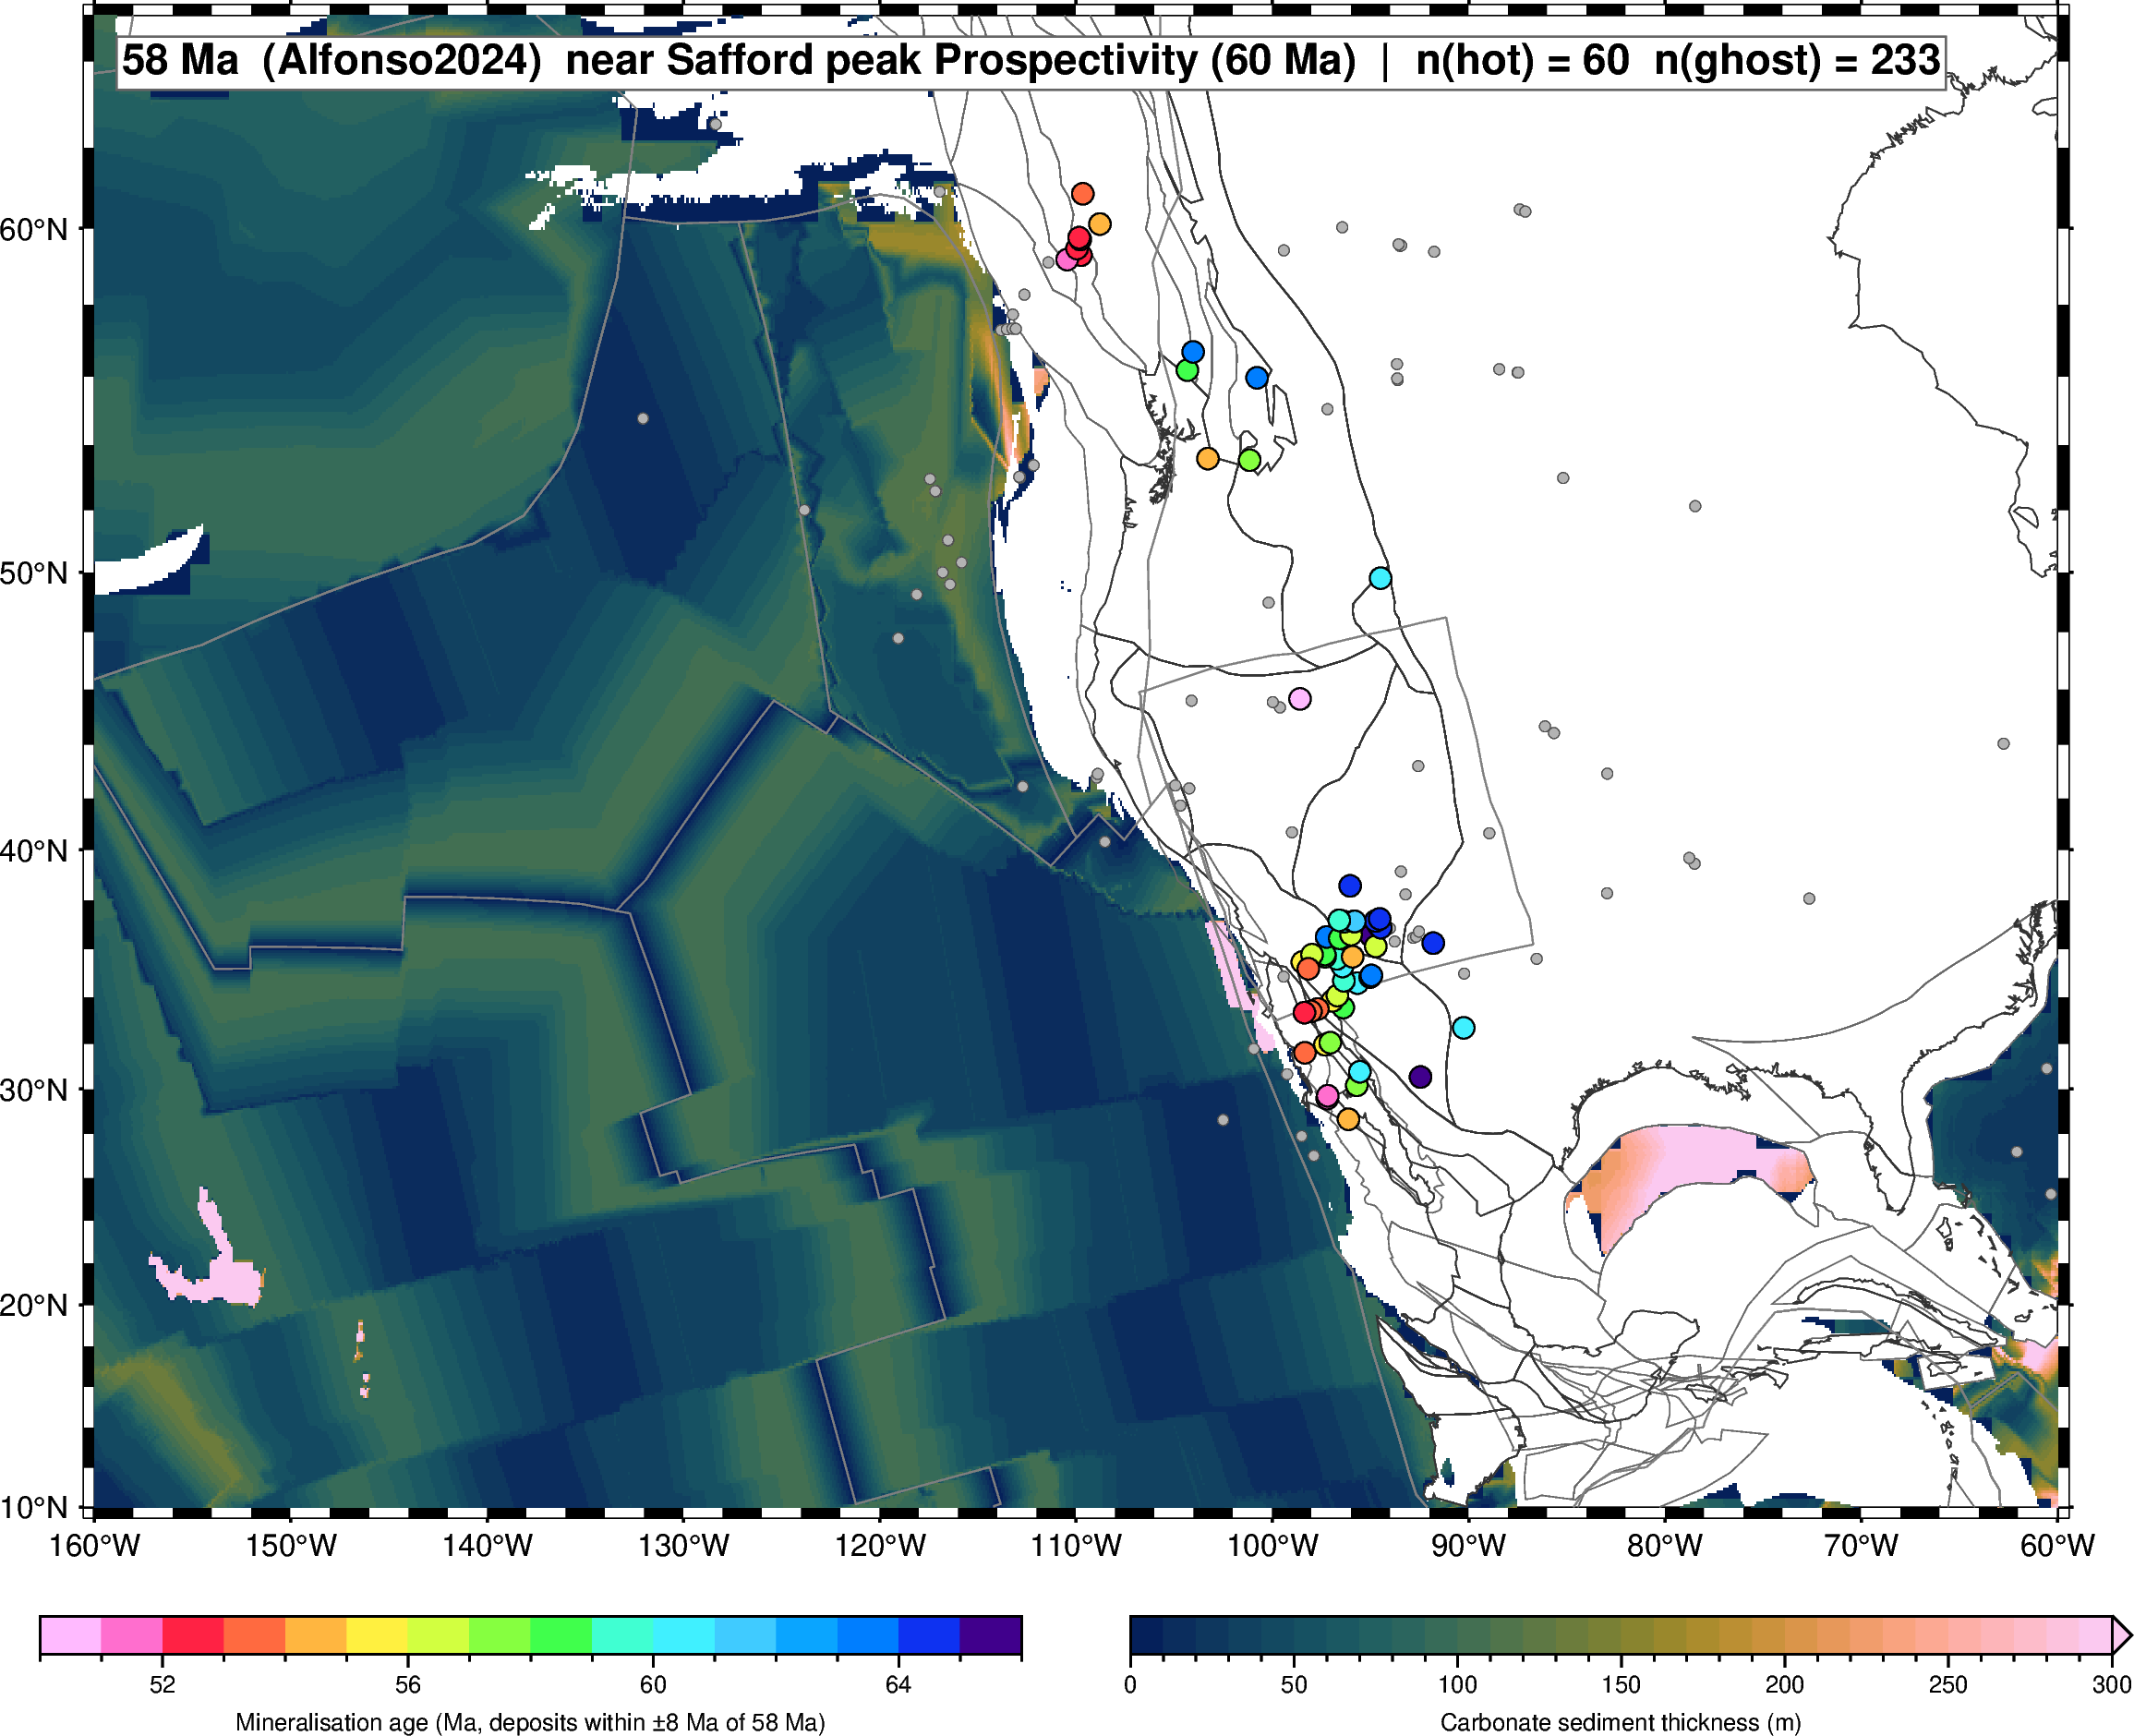

  25 Ma  (Glacier Peak peak 28 Ma):  raster range 0–2199 m


grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


    (skip continent overlay: AttributeError)


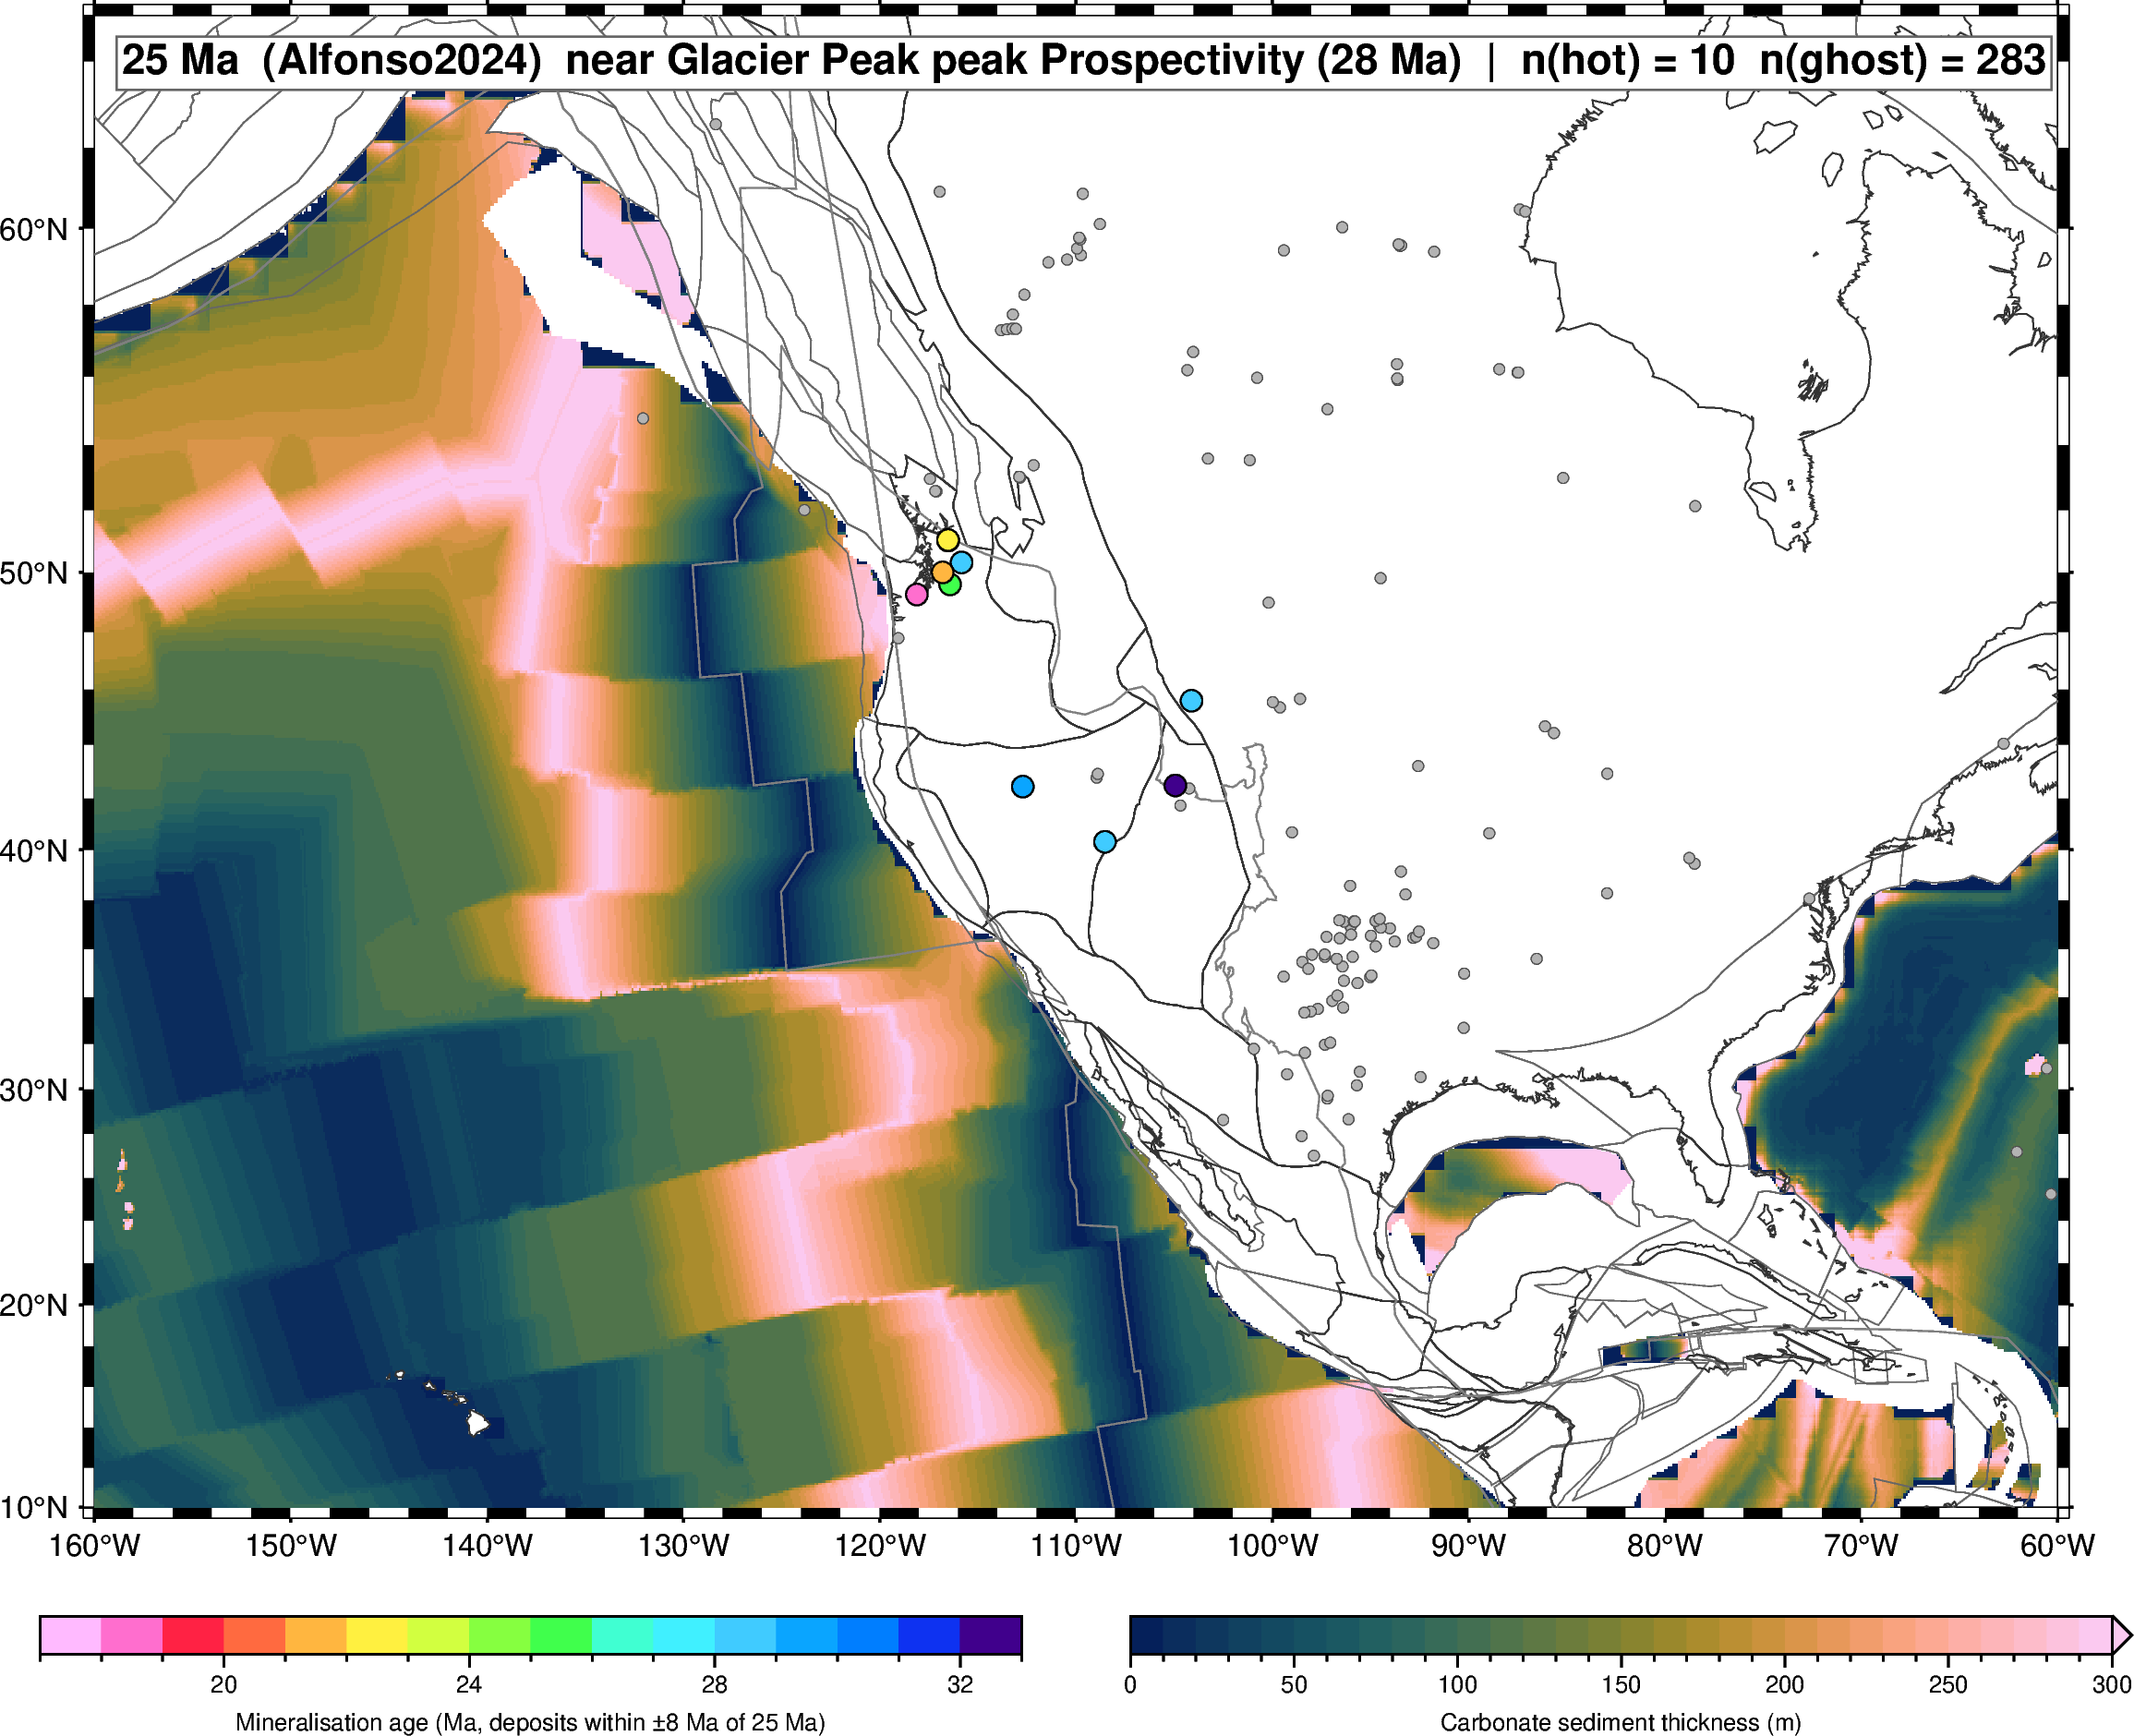

In [5]:
# --- Two maps, one per pre-computed carbonate-raster age ---
# The paper's shared archive gives us two snapshots (58 Ma and 25 Ma). The
# Prospectivity Score for Safford peaks at 60 Ma, for Glacier Peak at 28 Ma —
# both within a few Myr of one of these two rasters, so each map naturally
# contextualises one case-study deposit's peak fertility age.
CARB_MAPS = [
    {"age": 58, "case_study": "Safford",      "peak_age": 60,
     "raster": Path("data/deep_time_porphyry/uncompacted_carbonate_thickness_58Ma.nc")},
    {"age": 25, "case_study": "Glacier Peak", "peak_age": 28,
     "raster": Path("data/deep_time_porphyry/uncompacted_carbonate_thickness_25Ma.nc")},
]

# Window (± Ma) for colouring deposits near each map's age
WINDOW_HALF  = 8

# Carbonate CPT — batlow, 0–300 m; +ef overflow arrow signals > 300 m saturation
CARB_CPT_MAX = 300

for _spec in CARB_MAPS:
    _age       = _spec["age"]
    _dep_name  = _spec["case_study"]
    _peak_age  = _spec["peak_age"]
    _raster_p  = _spec["raster"]

    if not _raster_p.exists():
        print(f"  ⚠ carbonate raster missing at {_raster_p}; skipping {_age} Ma map")
        continue
    _ds = xr.open_dataset(_raster_p)
    _vn = list(_ds.data_vars)[0]
    _carb_da = _ds[_vn]
    print(f"  {_age} Ma  ({_dep_name} peak {_peak_age} Ma):  raster range "
          f"{float(_carb_da.min()):.0f}–{float(_carb_da.max()):.0f} m")

    # PlotTopologies snapshot at the raster's age
    _gplot = gplately.PlotTopologies(
        plate_reconstruction=recon,
        coastlines=model.get_coastlines(),
        continents=model.get_continental_polygons(),
        COBs=model.get_COBs(),
        time=float(_age),
        plot_engine=gplately.PygmtPlotEngine(),
    )

    # ±WINDOW_HALF Ma window around the map's age
    _in_window = ((dated_ok["age_ma"] >= _age - WINDOW_HALF)
                  & (dated_ok["age_ma"] <= _age + WINDOW_HALF))
    _hot   = dated_ok.loc[_in_window].copy()
    _ghost = dated_ok.loc[~_in_window]

    fig = pygmt.Figure()
    fig.basemap(region=REGION_CORDILLERA, projection="M18c",
                 frame=["af", "WSne"])

    # Carbonate base — batlow, clipped to 0–250 m, +ef overflow arrow
    pygmt.makecpt(cmap="batlow", series=[0, CARB_CPT_MAX, 10], background="o")
    try:
        fig.grdimage(grid=_carb_da, cmap=True, nan_transparent=True)
    except Exception as e:
        print(f"    (skip carbonate grdimage: {type(e).__name__})")

    # Continent + coastline + plate-topology overlay
    try:
        _gplot.plot_continents(fig, fill=None, pen="0.3p,gray40")
        _gplot.plot_coastlines(fig, pen="0.35p,gray20")
        _gplot.plot_all_topological_sections(fig, pen="0.4p,gray50")
        (_tl, _tr) = _gplot.get_subduction_direction()
        _gplot.plot_subduction_zones(fig, _tl, _tr, color="blue")
    except Exception as e:
        print(f"    (skip continent overlay: {type(e).__name__})")

    # Ghost deposits (outside window)
    if len(_ghost):
        fig.plot(x=_ghost["paleo_lon"], y=_ghost["paleo_lat"],
                  style="c0.10c", fill="gray70", pen="0.2p,gray30")

    # In-window deposits, coloured by mineralisation age
    if len(_hot):
        pygmt.makecpt(cmap="wysiwyg",
                       series=[_age - WINDOW_HALF, _age + WINDOW_HALF, 1],
                       background="o", reverse=True)
        fig.plot(x=_hot["paleo_lon"], y=_hot["paleo_lat"],
                  fill=_hot["age_ma"], cmap=True,
                  style="c0.20c", pen="0.4p,black")
        fig.colorbar(cmap=True, position="JBC+w9c/0.35c+h+o-5c/1c",
                      frame=[f"xa4f1+lMineralisation age (Ma, "
                              f"deposits within ±{WINDOW_HALF} Ma of {_age} Ma)"])

    # Carbonate colour bar — +ef adds the RIGHT-side overflow arrow
    pygmt.makecpt(cmap="batlow", series=[0, CARB_CPT_MAX, 10], background="o")
    fig.colorbar(cmap=True, position="JBC+w9c/0.35c+h+o5c/1c+ef",
                  frame=["xa50f10+lCarbonate sediment thickness (m)"])

    # Title stamp
    fig.text(text=(f"{_age} Ma  ({MODEL_NAME})  near {_dep_name} peak Prospectivity "
                    f"({_peak_age} Ma)  |  n(hot) = {len(_hot)}  n(ghost) = {len(_ghost)}"),
             position="TL", offset="0.25c/-0.25c", justify="TL",
             font="11p,Helvetica-Bold,black", fill="white", pen="0.5p,gray40")
    fig.show(width=1100)


### How to read these two maps

Both maps use the same batlow palette and the same 0-300 m range so you can compare the two ages directly; the arrow at the right end of the colour bar flags that values above 300 m saturate to the top-end batlow colour. Bright yellow patches under the western Cordilleran margin are where the paper's reconstruction places the thickest carbonate-sediment column entering the trench at that age.

- **58 Ma map** — near Safford's 60 Ma peak Prospectivity. Safford itself mineralised 10 Myr later at 48 Ma, so it doesn't appear as a coloured circle here (it's outside the ±8 Ma window around 58 Ma). That 10 Myr gap between fertility onset and mineralisation is the "small positive lag" §5 documents.
- **25 Ma map** — near Glacier Peak's 28 Ma peak Prospectivity. Same 7 Myr peak-to-mineralisation lag (mineralisation at 21 Ma).

Watch for the spatial coincidence: WYSIWYG-coloured hot deposits should cluster where the batlow raster is at its brightest (thickest subducting carbonate).


## 4. Deposit trajectories: feature time-series

For each case-study deposit, plot the pre-computed time-series of features from Alfonso 2024 through the Cenozoic. The paper considers 31 features; this notebook focuses on the four that drove the strongest signal in the ML feature-importance analysis:

- **Subducted-carbonate volume** — the fertility trigger
- **Convergence rate** — total plate-motion component driving subduction
- **Convergence obliquity** — angle between convergence direction and margin normal
- **Crustal thickness (mean)** — over-riding-plate architecture

A vertical grey band marks each deposit's canonical mineralisation age.


  loaded trajectory data: 82 (deposit, age) rows
  case-study deposits: ['Glacier Peak', 'Safford']


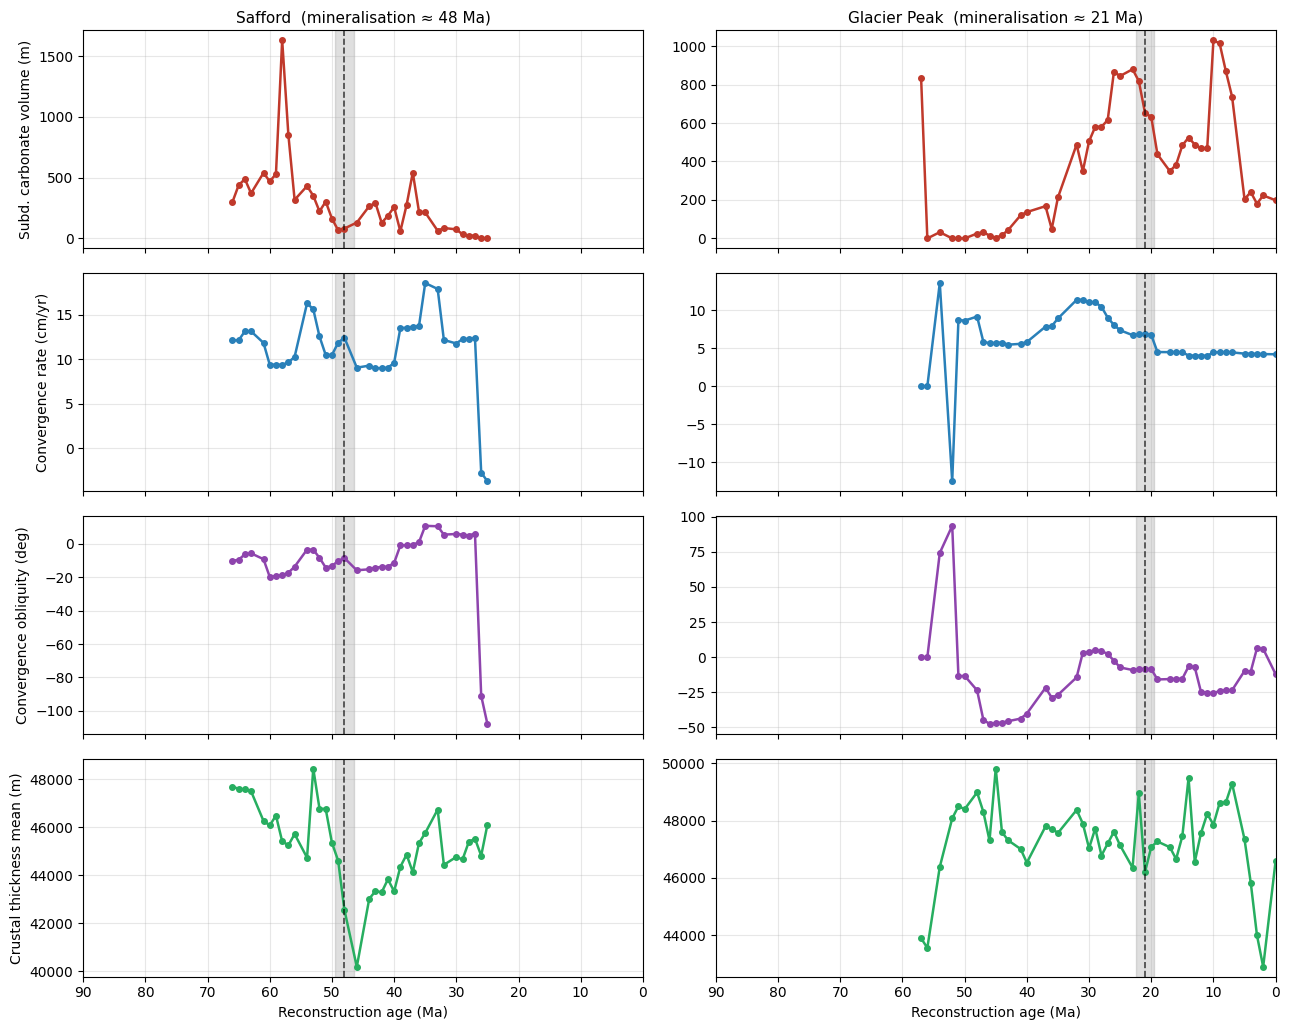

In [6]:
trajectories = pd.read_csv(TRAJECTORY_CSV)
print(f"  loaded trajectory data: {len(trajectories):,} (deposit, age) rows")
print(f"  case-study deposits: {sorted(trajectories['deposit'].unique())}")

# Ensure the case-study deposits are in the file
missing = [d for d in CASE_STUDIES if d not in trajectories["deposit"].values]
if missing:
    raise ValueError(f"Case-study deposit(s) not in trajectory CSV: {missing}")

FEATURES = [
    ("subducted_carbonates_volume (m)", "Subd. carbonate volume (m)", "#c0392b"),
    ("convergence_rate (cm/yr)",        "Convergence rate (cm/yr)",   "#2980b9"),
    ("convergence_obliquity (degrees)", "Convergence obliquity (deg)", "#8e44ad"),
    ("crustal_thickness_mean (m)",     "Crustal thickness mean (m)",  "#27ae60"),
]

n_dep = len(CASE_STUDIES)
fig, axes = plt.subplots(len(FEATURES), n_dep,
                          figsize=(6.5 * n_dep, 2.6 * len(FEATURES)),
                          sharex=True)
if n_dep == 1: axes = axes.reshape(-1, 1)

for _j, dep in enumerate(CASE_STUDIES):
    sub = trajectories.loc[trajectories["deposit"] == dep].sort_values("age (Ma)")
    _mineral_age = float(sub["mineralization_age"].iloc[0])
    for _i, (col, label, colr) in enumerate(FEATURES):
        ax = axes[_i, _j]
        if col not in sub.columns:
            ax.text(0.5, 0.5, f"missing: {col}", transform=ax.transAxes,
                     ha="center", va="center")
            continue
        ax.plot(sub["age (Ma)"], sub[col], color=colr, lw=1.8,
                 marker="o", markersize=4)
        # Mineralisation-age vertical band
        ax.axvspan(_mineral_age - 1.5, _mineral_age + 1.5,
                    color="gray", alpha=0.25)
        ax.axvline(_mineral_age, color="black", lw=1.2, ls="--", alpha=0.7)
        ax.grid(alpha=0.3)
        if _i == 0:
            ax.set_title(f"{dep}  (mineralisation ≈ {_mineral_age:.0f} Ma)",
                          fontsize=11)
        if _j == 0:
            ax.set_ylabel(label, fontsize=10)
        if _i == len(FEATURES) - 1:
            ax.set_xlabel("Reconstruction age (Ma)")
        ax.set_xlim(0, TS_AGE_MAX_MA)
        ax.invert_xaxis()

plt.tight_layout()
plt.show()


### What these trajectories show

Reading down each column tells you the feature history experienced by that deposit's paleo-position through the Cenozoic. Reading across the row lets you compare the two case studies against each other for the same variable.

Safford mineralised at 48 Ma, Glacier Peak at 21 Ma (grey bands, one per deposit column). Look for the following:

- **Subducted-carbonate volume** — should show a broad peak or plateau at or a few Myr before the mineralisation age, consistent with the "carbonate-fertility" hypothesis. (Peak subducted-carbonate flux typically precedes deposit formation by ~5-15 Myr — the fertility-onset-to-mineralisation lag §5 documents.) If it's flat, the classical carbonate-fertility signal is weak for that deposit.
- **Convergence rate** — moderate-to-high convergence (4-10 cm/yr) accompanies most active-margin porphyry-Cu formation. Pre-mineralisation acceleration is diagnostic of the plate-reorganisation trigger.
- **Convergence obliquity** — moderate values (~10-30°) tend to accompany porphyry-Cu emplacement; extreme orthogonality can stall arc magmatism, extreme obliquity drives transtension rather than compression.
- **Crustal thickness (mean)** — over-riding plate architecture. Thick crust (> 40 km) traps the exsolving fluids where the porphyry-Cu deposits form.

The paper's headline finding is that these four factors have to line up **simultaneously** for a fertility window to open; the Cordillera has crossed that threshold a small number of times through the Cenozoic.


## 5. Prospectivity score vs actual mineralisation

The paper's spatiotemporal ML model outputs a **Prospectivity Score** at every (deposit, age) tuple in the trajectory table — a 0-1 posterior probability that the deposit would form at that age given the local conditions. Overlaying this score on each case-study trajectory shows how well the model's independent prediction lines up with the observed mineralisation age.


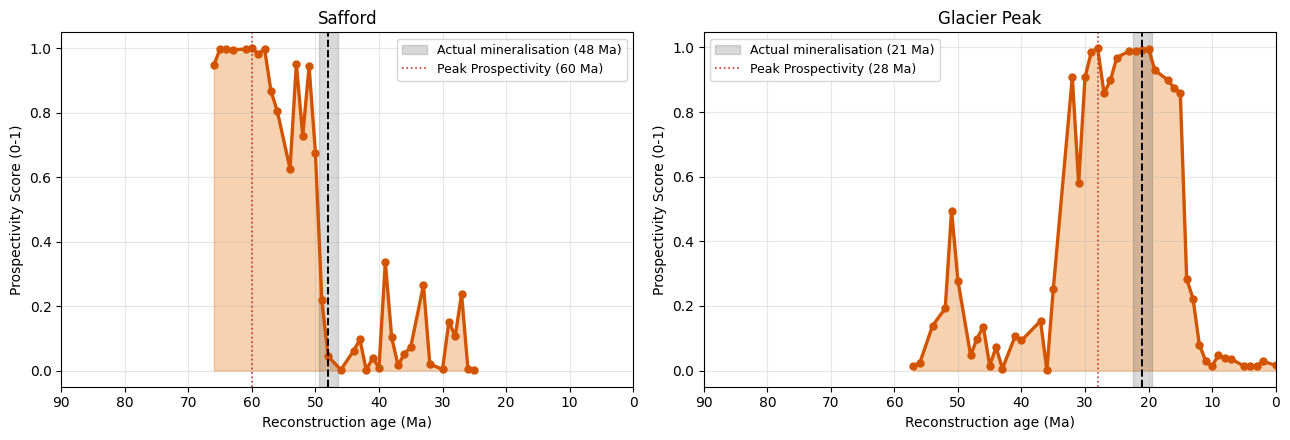

  Safford        : mineralisation 48 Ma, peak prospectivity 60 Ma  → lag +12 Myr (model too early)
  Glacier Peak   : mineralisation 21 Ma, peak prospectivity 28 Ma  → lag +7 Myr (model too early)


In [7]:
fig, axes = plt.subplots(1, len(CASE_STUDIES),
                          figsize=(6.5 * len(CASE_STUDIES), 4.5), sharey=False)
if len(CASE_STUDIES) == 1: axes = [axes]

for ax, dep in zip(axes, CASE_STUDIES):
    sub = trajectories.loc[trajectories["deposit"] == dep].sort_values("age (Ma)")
    _mineral_age = float(sub["mineralization_age"].iloc[0])

    # Prospectivity Score line + fill
    ax.fill_between(sub["age (Ma)"], sub["Prospectivity Score"], 0,
                    color="#e67e22", alpha=0.35)
    ax.plot(sub["age (Ma)"], sub["Prospectivity Score"],
             color="#d35400", lw=2.4, marker="o", markersize=5)

    # Mineralisation-age band
    ax.axvspan(_mineral_age - 1.5, _mineral_age + 1.5,
                color="black", alpha=0.15,
                label=f"Actual mineralisation ({_mineral_age:.0f} Ma)")
    ax.axvline(_mineral_age, color="black", lw=1.4, ls="--")

    # Peak-prospectivity age
    _peak_row = sub.loc[sub["Prospectivity Score"].idxmax()]
    ax.axvline(_peak_row["age (Ma)"], color="#c0392b", lw=1.2, ls=":",
                label=f"Peak Prospectivity ({_peak_row['age (Ma)']:.0f} Ma)")

    ax.set_title(f"{dep}")
    ax.set_xlabel("Reconstruction age (Ma)")
    ax.set_ylabel("Prospectivity Score (0-1)")
    ax.grid(alpha=0.3)
    # Move Glacier Peak's legend to the left so it doesn't overlap the
    # deposit's late-Miocene / recent Prospectivity Score peak.
    _legend_loc = "upper left" if dep == "Glacier Peak" else "upper right"
    ax.legend(loc=_legend_loc, fontsize=9)
    ax.set_xlim(0, TS_AGE_MAX_MA)
    ax.invert_xaxis()

plt.tight_layout()
plt.show()

# Numeric summary — lag between peak-prospectivity age and actual mineralisation
for dep in CASE_STUDIES:
    sub = trajectories.loc[trajectories["deposit"] == dep]
    _mineral_age = float(sub["mineralization_age"].iloc[0])
    _peak_row = sub.loc[sub["Prospectivity Score"].idxmax()]
    _peak_age = float(_peak_row["age (Ma)"])
    _lag = _peak_age - _mineral_age
    print(f"  {dep:15s}: mineralisation {_mineral_age:.0f} Ma, "
          f"peak prospectivity {_peak_age:.0f} Ma  → "
          f"lag {_lag:+.0f} Myr {'(model too early)' if _lag > 0 else '(model too late)' if _lag < 0 else '(exact match)'}")


### What the prospectivity trajectory tells you

A model that correctly identifies transient fertility windows should have its **peak Prospectivity Score** landing near the deposit's actual mineralisation age. The vertical dashed lines show that comparison directly:

- **Zero lag** — the model's peak is at the same age as the deposit → the features alone (independent of geochronology) tell us the deposit should have formed then.
- **Small positive lag** (peak 5-10 Myr older than mineralisation) — the model recognises the fertility conditions but predicts formation slightly early. This is the expected pattern: the fertility conditions have to persist for some time before magma-collection and fluid-exsolution actually deliver a deposit.
- **Large lag** in either direction — the model is missing something (a rapid plate-reorganisation trigger, or a local feature not captured by the six variables here).

A model that scores well across both Safford and Glacier Peak in this test — small, positive lags — is evidence that the fertility-window hypothesis works out of sample and can be applied to guide exploration in less-well-explored NA belts.


## 6. Cross-variable analysis: which feature drives the peak?

For each case study, correlate the Prospectivity Score against each individual feature across the deposit's trajectory. Features with the highest positive correlation are what the model is "watching" to identify a fertility window.


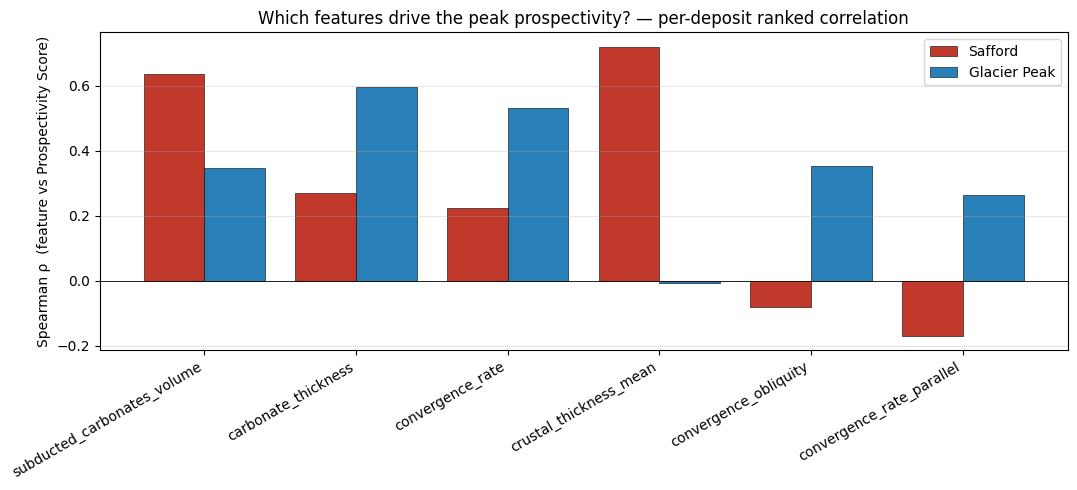


  full correlation table:
     deposit                           feature       rho            p  n
Glacier Peak           carbonate_thickness (m)  0.597404 1.169687e-05 46
Glacier Peak          convergence_rate (cm/yr)  0.530451 1.494776e-04 46
Glacier Peak   convergence_obliquity (degrees)  0.352462 1.628859e-02 46
Glacier Peak   subducted_carbonates_volume (m)  0.347193 1.807712e-02 46
Glacier Peak convergence_rate_parallel (cm/yr)  0.262789 7.765931e-02 46
Glacier Peak        crustal_thickness_mean (m) -0.005612 9.704724e-01 46
     Safford        crustal_thickness_mean (m)  0.720206 7.346639e-07 36
     Safford   subducted_carbonates_volume (m)  0.637838 2.858212e-05 36
     Safford           carbonate_thickness (m)  0.269958 1.113157e-01 36
     Safford          convergence_rate (cm/yr)  0.222909 1.912929e-01 36
     Safford   convergence_obliquity (degrees) -0.080824 6.393588e-01 36
     Safford convergence_rate_parallel (cm/yr) -0.168082 3.271368e-01 36


In [8]:
from scipy.stats import spearmanr

FEATURE_COLS = [
    "subducted_carbonates_volume (m)",
    "carbonate_thickness (m)",
    "convergence_rate (cm/yr)",
    "convergence_rate_parallel (cm/yr)",
    "convergence_obliquity (degrees)",
    "crustal_thickness_mean (m)",
]

rows = []
for dep in CASE_STUDIES:
    sub = trajectories.loc[trajectories["deposit"] == dep]
    for col in FEATURE_COLS:
        if col not in sub.columns: continue
        _pair = sub[[col, "Prospectivity Score"]].dropna()
        if len(_pair) < 3: continue
        rho, p = spearmanr(_pair[col], _pair["Prospectivity Score"])
        rows.append({"deposit": dep, "feature": col,
                     "rho": float(rho), "p": float(p), "n": int(len(_pair))})
corr = pd.DataFrame(rows)

# Bar chart — sort features by absolute rho, one bar per (deposit, feature)
fig, ax = plt.subplots(figsize=(11, 5))
palette = {CASE_STUDIES[0]: "#c0392b", CASE_STUDIES[1]: "#2980b9"} if len(CASE_STUDIES) >= 2 else            {CASE_STUDIES[0]: "#c0392b"}
feature_order = (corr.groupby("feature")["rho"].mean().abs()
                     .sort_values(ascending=False).index.tolist())
x = np.arange(len(feature_order))
w = 0.4
for _k, dep in enumerate(CASE_STUDIES):
    sub = corr[corr["deposit"] == dep].set_index("feature").reindex(feature_order)
    ax.bar(x + (_k - (len(CASE_STUDIES)-1)/2)*w, sub["rho"],
           w, color=palette.get(dep, "gray"), edgecolor="black",
           linewidth=0.4, label=dep)
ax.axhline(0, color="black", lw=0.6)
ax.set_xticks(x)
ax.set_xticklabels([c.split(" (")[0] for c in feature_order],
                    rotation=30, ha="right")
ax.set_ylabel("Spearman ρ  (feature vs Prospectivity Score)")
ax.set_title("Which features drive the peak prospectivity? — "
              "per-deposit ranked correlation")
ax.grid(alpha=0.3, axis="y")
ax.legend()
plt.tight_layout()
plt.show()

print("\n  full correlation table:")
print(corr.sort_values(["deposit", "rho"], ascending=[True, False]).to_string(index=False))


### What the correlation panel shows

For each deposit, the bars are Spearman ρ between the feature and the ML Prospectivity Score across the trajectory. A **strongly positive** bar means "when this feature was high, the model predicted higher prospectivity"; a **strongly negative** bar means the reverse.

Order-of-magnitude expectations (paper's headline features):

- `subducted_carbonates_volume (m)` and `carbonate_thickness (m)` should have the strongest positive bars — the ML model was designed to detect the carbonate-fertility signal.
- `crustal_thickness_mean (m)` should also be strongly positive — over-riding-plate architecture is a first-order fertility control.
- `convergence_rate (cm/yr)` should be positive but weaker — moderate-to-fast convergence is a necessary but insufficient condition.
- `convergence_obliquity (degrees)` could be positive OR negative depending on which end of the obliquity spectrum the mineralisation window sits at.

Comparison between the two deposits tells you whether the same features drive prospectivity everywhere in the Cordillera, or whether the "recipe" differs regionally.


## 7. Permutation importance — surrogate feature ranking

Spearman ρ (§6) captures the strength of the marginal monotone relationship between one feature and the Prospectivity Score. **Permutation importance** is a stricter test: fit a small surrogate regressor to reproduce the paper's Prospectivity Score from all six features jointly, then for each feature ask *"how much worse does the model do if I randomly shuffle this column?"* Large drops in performance = the model actually relied on that feature; small drops = the feature was redundant with the others.

**Caveat**: this is a surrogate model fitted on the combined Safford + Glacier Peak trajectories (82 rows), NOT the paper's full continent-scale model. It's a directional feature-importance indicator — use §6 correlations for interpretation, and the paper for the authoritative model.


  surrogate training set: 82 rows × 6 features (Safford + Glacier Peak combined)
  surrogate R² on training set: 1.000


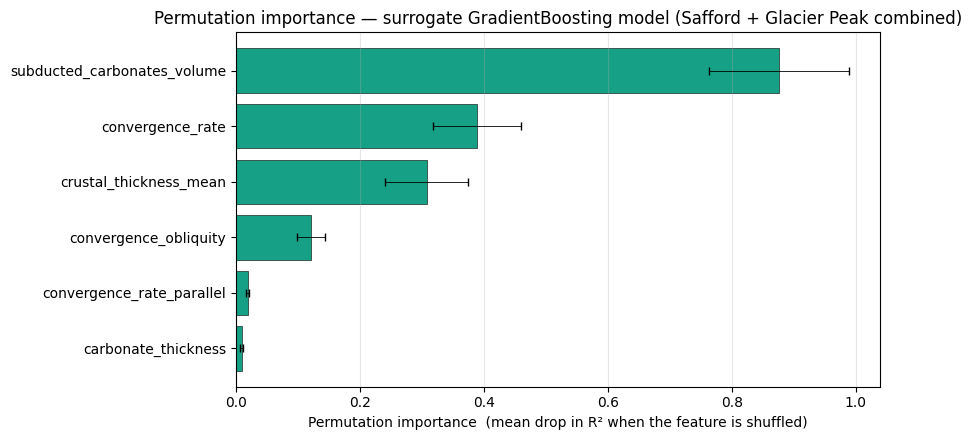


  Permutation importance table (mean ± std of R² drop):
    subducted_carbonates_volume (m)         +0.8765 ± 0.1134
    convergence_rate (cm/yr)                +0.3885 ± 0.0711
    crustal_thickness_mean (m)              +0.3079 ± 0.0665
    convergence_obliquity (degrees)         +0.1210 ± 0.0227
    convergence_rate_parallel (cm/yr)       +0.0189 ± 0.0024
    carbonate_thickness (m)                 +0.0091 ± 0.0018


In [9]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import permutation_importance

FEATURE_COLS = [
    "subducted_carbonates_volume (m)",
    "carbonate_thickness (m)",
    "convergence_rate (cm/yr)",
    "convergence_rate_parallel (cm/yr)",
    "convergence_obliquity (degrees)",
    "crustal_thickness_mean (m)",
]

# Combine both case-study deposits into one training set
combined = trajectories.loc[trajectories["deposit"].isin(CASE_STUDIES)].copy()
combined = combined.dropna(subset=FEATURE_COLS + ["Prospectivity Score"])
X = combined[FEATURE_COLS].to_numpy()
y = combined["Prospectivity Score"].to_numpy()
print(f"  surrogate training set: {X.shape[0]} rows × {X.shape[1]} features "
      f"(Safford + Glacier Peak combined)")

# Small gradient-boosted surrogate model
reg = GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=0)
reg.fit(X, y)
print(f"  surrogate R² on training set: {reg.score(X, y):.3f}")

# Permutation importance — 50 shuffles per feature
result = permutation_importance(reg, X, y, n_repeats=50, random_state=0,
                                 scoring="r2")
order = np.argsort(result.importances_mean)  # ascending, so worst at bottom

fig, ax = plt.subplots(figsize=(9, 4.5))
_labels = [FEATURE_COLS[k].split(" (")[0] for k in order]
_means  = result.importances_mean[order]
_stds   = result.importances_std[order]
ax.barh(np.arange(len(order)), _means, xerr=_stds,
         color="#16a085", edgecolor="black", linewidth=0.4,
         error_kw={"ecolor": "black", "capsize": 3, "elinewidth": 0.6})
ax.axvline(0, color="black", lw=0.6)
ax.set_yticks(np.arange(len(order)))
ax.set_yticklabels(_labels, fontsize=10)
ax.set_xlabel("Permutation importance  (mean drop in R² when the feature is shuffled)")
ax.set_title("Permutation importance — surrogate GradientBoosting model "
              "(Safford + Glacier Peak combined)")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

print("\n  Permutation importance table (mean ± std of R² drop):")
for k in order[::-1]:
    print(f"    {FEATURE_COLS[k]:38s}  "
          f"{result.importances_mean[k]:+.4f} ± {result.importances_std[k]:.4f}")


### What the permutation importance panel shows

Bars extending to the right = shuffling that feature hurts the surrogate model the most, so the model "leans on" that feature. Bars near zero (or slightly negative) = the surrogate can predict the Prospectivity Score just as well when that feature is randomised, so the feature was redundant with the others already in the set.

Compare against §6:

- A feature with **high permutation importance** *and* **high Spearman ρ** — unambiguously the strongest predictor. This is the paper's headline result if it lands on `subducted_carbonates_volume` and `carbonate_thickness`.
- A feature with **high permutation importance** but **low Spearman ρ** — non-monotonic contribution (e.g. the feature matters at intermediate values but not at extremes). Convergence obliquity often behaves this way.
- A feature with **low permutation importance** but **high Spearman ρ** — redundant with a stronger neighbour (e.g. `carbonate_thickness` might be redundant with `subducted_carbonates_volume`).
- A feature with **low permutation importance** and **low Spearman ρ** — either unimportant or genuinely uncorrelated with prospectivity in this two-deposit sample.

The surrogate is small and fits fast, so you can rerun the cell after adding your own case-study deposits to `CASE_STUDIES` and see how the ranking shifts.


## Extend this

- **Add more case-study deposits.** Any deposit in the paper's spatiotemporal training set has a full pre-computed trajectory. Ask the paper authors for the extended trajectory CSV, or generate additional trajectories with `pyDTDM.spatiotemporal_sampling` (see the paper's `PreprocessingPorphyrycoppersample.ipynb` for the recipe).
- **Rerun against a different plate model.** Merdith 2021 covers 0-1000 Ma but was not tuned to the North American Cordillera as tightly as Alfonso 2024. Compare the resulting trajectories to see how sensitive the fertility signal is to the plate-model choice. The Zahirovic 2022 comparison would be useful too — it's what the current suite defaults to elsewhere.
- **Extend to global porphyry belts.** The paper's method is North America-only; applying it to the Andean or SW-Pacific belts (see T55) would test transferability and let you compare fertility windows across ocean basins.
- **Overlay the ML prospectivity grids on the paleo-Earth map.** T59's sibling notebook (planned) will load the paper's three prospectivity NetCDFs and plot them at multiple Cenozoic snapshots. That extends this case-study view into a spatially-continuous prospectivity map.
- **Test the "peak lag" hypothesis** on a batch of deposits. If the peak-prospectivity age is consistently 5-10 Myr older than the mineralisation age across many deposits, that's a diagnostic of the delay between fertility onset and actual deposit formation — useful for exploration timing.

## Related resources — Geonome

The Norbisrath et al. porphyry-Cu prospectivity workflow is part of **Geonome** ([geonome.com.au](https://geonome.com.au/#home)) — an EarthByte-led open initiative for AI-driven deep-time mineral prospectivity. The tutorial companion for this exact use case lives at [geonome.com.au/tutorials/ai-mineral-prospectivity.html](https://geonome.com.au/tutorials/ai-mineral-prospectivity.html) and walks through the broader pipeline: data preparation, feature engineering, model training, and deposit-inventory management, plus the equivalent workflows for other commodity systems. This notebook only touches the visualisation + interpretation end; the Geonome tutorial covers everything upstream of it.

## References

- Norbisrath, J.H., Singh, S.P., Singh, U., Müller, R.D. (submitted 2026). *Plate reorganisation and carbonate subduction create transient porphyry copper fertility windows*. *Geology*. Data + code: PolyForm Noncommercial 1.0.0 / CC BY-NC 4.0.
- Alfonso, C.P., Müller, R.D., Cannon, J., Wright, N., Ford, J., Chin, M. (2024). A deep-time plate model of the North American Cordillera and adjacent Pacific plate system 250 Ma to present. *Earth-Science Reviews* 250, 104692.
- Hammarstrom, J.M., et al. (2010). *Global assessment of undiscovered copper resources*. USGS Scientific Investigations Report 2010-5090.
- Singer, D.A., Berger, V.I., Moring, B.C. (2008). *Porphyry copper deposits of the world: database and grade and tonnage models*. USGS Open-File Report 2008-1155.
- Mather, B.R., Müller, R.D., Alfonso, C., Wright, N.M., Seton, M. (2025). Subducting seafloor anomalies promote porphyry copper formation. *International Geology Review* 67(19), 2170-2186. — background reading for the same Alfonso 2024 workflow applied to the SW-Pacific porphyry belt (T57).
